## Построение D-разбиения для фиксированной ECM-моды

Данная ячейка строит D-разбиение на плоскости параметров обратной связи $$ (\gamma, h) $$ для выбранной внешнекаверной моды (External Cavity Mode, ECM) полупроводникового лазера с задержанной обратной связью.

### Назначение

Целью расчета является определение границ потери устойчивости стационарного решения. D-разбиение представляет собой множество точек параметрического пространства, в которых характеристическое уравнение имеет чисто мнимые корни

$$
\lambda = i\omega,
$$

что соответствует бифуркации устойчивости.

Полученные кривые разделяют область параметров на зоны с различным спектральным составом характеристических корней и, следовательно, с различным типом динамики.

---

## ECM-моды

Для каждой пары параметров $$ (\gamma,h) $$ стационарные решения определяются из ECM-уравнения

$$
\eta
-
\omega_0 h
+
\gamma h \sqrt{1+\alpha^2}
\sin(\left(
\eta+\arctan(\alpha)
\right)
=
0.$$

Каждое решение данного уравнения соответствует отдельной внешнекаверной моде.

В коде исследуется только одна непрерывно продолжаемая ветвь ECM-мод, задаваемая параметром

```python
TARGET_ETA
```

который определяет фазу выбранной моды.

---

## Выбор одной физической ветви

Поскольку ECM-уравнение может иметь множество решений, необходимо отслеживать одну и ту же моду при изменении параметров.

Для этого используется процедура продолжения по параметрам:

1. Выбирается начальная точка (anchor point).
2. Находится корень $\eta_{seed}$, ближайший к заданному значению `TARGET_ETA`.
3. При дальнейшем движении по параметрическому пространству выбирается корень, ближайший к предыдущему значению $\eta$.
4. Если соответствующий корень исчезает или происходит скачок на другую ветвь, продолжение прекращается.

Таким образом каждая D-кривая строится для одной и той же ECM-моды.

---

## Характеристическое уравнение

Для выбранной ECM-моды анализируется характеристическое уравнение линеаризованной системы

$$
F(\lambda,\gamma,h,\eta)=0.
$$

На границе устойчивости выполняется условие

$$
\lambda=i\omega.
$$

Подстановка чисто мнимого корня приводит к системе двух вещественных уравнений

$$
\operatorname{Re}F(i\omega)=0,
$$

$$
\operatorname{Im}F(i\omega)=0.
$$

Именно эта система решается численно методом Ньютона (`fsolve`) для различных значений частоты $$\omega$$.

---

## Поиск стартовых точек

Для обнаружения всех возможных D-кривых выполняется сканирование по частоте

$$
\omega \in
[\omega_{\min},\omega_{\max}].
$$

Для каждого значения частоты используются различные начальные приближения по параметрам

$$
(\gamma,h),
$$

после чего ищутся решения системы

$$
\operatorname{Re}F(i\omega)=0,
\qquad
\operatorname{Im}F(i\omega)=0.
$$

Полученные решения используются как стартовые точки для дальнейшего продолжения ветвей.

---

## Продолжение D-кривых

После нахождения стартовой точки используется метод параметрического продолжения.

Продолжение выполняется в обе стороны по частоте:

$$
\omega \rightarrow \omega \pm \Delta\omega.
$$

На каждом шаге:

* используется предиктор по предыдущим точкам;
* выполняется коррекция методом `fsolve`;
* контролируется величина шага;
* проверяется отсутствие перескока на другую ECM-моду;
* контролируется гладкость геометрии ветви.

Если какая-либо проверка не выполняется, шаг уменьшается либо построение ветви завершается.

---

## Визуализация

На итоговом графике отображаются найденные D-кривые на плоскости параметров $
(\gamma,h).
$

Здесь:

* $\gamma$ — коэффициент обратной связи;
* $h$ — время задержки во внешнем резонаторе.

Каждая кривая соответствует условию появления пары чисто мнимых характеристических корней.

Переход через такую кривую связан с изменением устойчивости исследуемой ECM-моды.

---

## Основные параметры расчета

### Параметры модели

```python
alpha
v
omega0
```

* фактор уширения линии;
* параметр инверсии;
* частотная отстройка.

### Параметры области исследования

```python
GAMMA_MIN
GAMMA_MAX

H_MIN
H_MAX
```

определяют прямоугольную область построения D-разбиения.

### Параметры выбора моды

```python
TARGET_ETA
TARGET_MATCH_TOL
LOCAL_BRANCH_TOL
```

управляют идентификацией и непрерывным отслеживанием одной ECM-ветви.

### Параметры продолжения

```python
OMEGA_MIN_BRANCH
OMEGA_MAX_BRANCH
```

задают диапазон исследуемых частот.

---

## Интерпретация результатов

Полученные D-кривые являются границами изменения устойчивости фиксированной ECM-моды.

Области, разделённые этими кривыми, могут соответствовать:

* устойчивым стационарным решениям;
* периодическим режимам;
* квазипериодическим режимам;
* хаотической динамике.

Для окончательной классификации режимов рекомендуется дополнительно использовать:

* временные реализации;
* фазовые портреты;
* отображения максимумов;
* показатели Ляпунова;
* спектральный анализ.


Chosen mode for this run
TARGET_ETA = 10.67134323
ANCHOR     = (2.0, 2.0)
eta_seed   = 10.643937572615743
Стартовых точек: 282
Найдено ветвей: 218


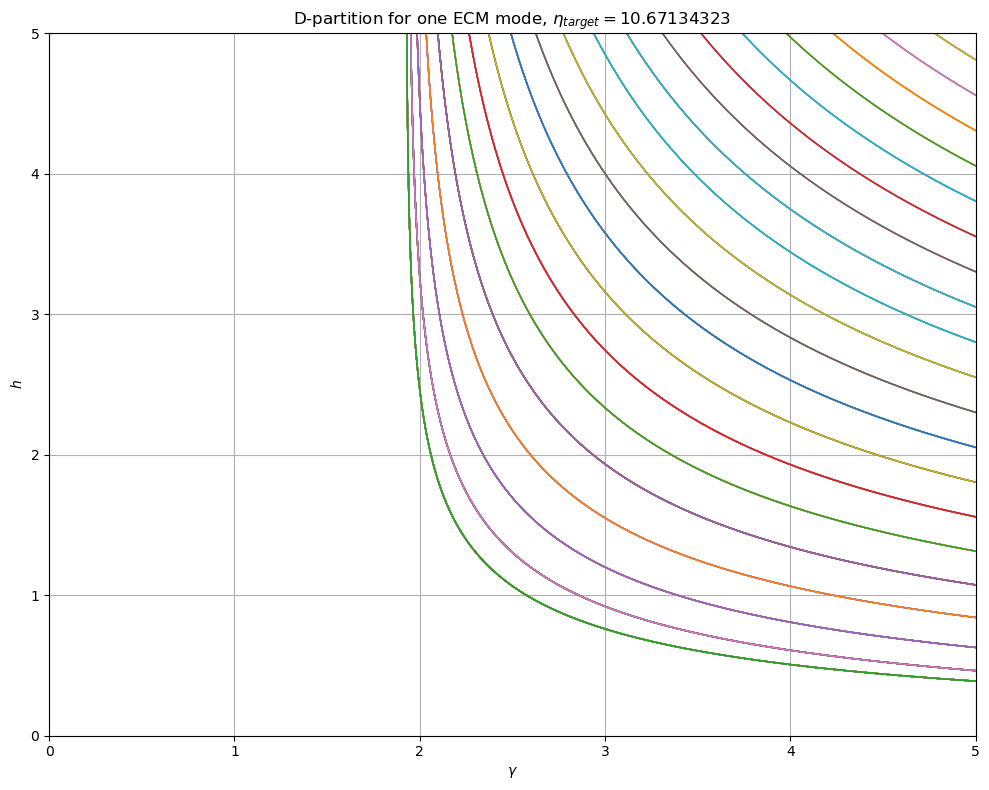

In [1]:
import numpy as np
from scipy.optimize import fsolve, root_scalar
import matplotlib.pyplot as plt

# ============================================================
#                    ПАРАМЕТРЫ МОДЕЛИ
# ============================================================

v = 10.0
alpha = 5.0
omega0 = 0.0

# ============================================================
#             ОБЛАСТЬ ПОСТРОЕНИЯ D-РАЗБИЕНИЯ
# ============================================================

GAMMA_MIN = 0.0
GAMMA_MAX = 20.0
H_MIN = 0.0
H_MAX = 20.0

def inside_domain(gamma, h):
    return (
        GAMMA_MIN <= gamma <= GAMMA_MAX
        and
        H_MIN <= h <= H_MAX
    )

# ============================================================
#         ВЫБОР ОДНОЙ КОНКРЕТНОЙ ECM-МОДЫ
# ============================================================
#
# IMPORTANT:
# TARGET_ETA задается в НЕразвернутом виде.
# Никакой свертки по mod 2*pi здесь не делаем.
#
# Пример:
#   TARGET_ETA = -7.63319343
#   TARGET_ETA = -np.arctan(alpha)
#   TARGET_ETA = 0.0
#
# ============================================================

TARGET_ETA = 10.67134323

# Насколько близко к TARGET_ETA должна быть стартовая мода
TARGET_MATCH_TOL = 1.5

# Насколько далеко можно отходить от предыдущей eta_ref
# при продолжении той же ветви.
LOCAL_BRANCH_TOL = 0.8

# Кандидаты на anchor point.
# Лучше держать здесь точки, где нужная мода реально может существовать.
ANCHOR_CANDIDATES = [
    (1.0, 1.5),
    (1.0, 2.0),
    (1.5, 1.5),
    (2.0, 1.5),
    (2.0, 2.0),
    (3.0, 3.0),
    (4.0, 4.0),
    (8.0, 8.0),
]

# Для отсечения слишком низкочастотных подозрительных ветвей
OMEGA_MIN_BRANCH = 0.15
OMEGA_MAX_BRANCH = 30.0

# ============================================================
#                 ECM УРАВНЕНИЕ И ПОИСК КОРНЕЙ
# ============================================================

def ecm_equation(eta, gamma, h):
    """
    ECM-уравнение:
        eta - omega0*h + C*sin(eta + arctan(alpha)) = 0
    где C = gamma*h*sqrt(1 + alpha^2)
    """
    C = gamma * h * np.sqrt(1 + alpha**2)
    return eta - omega0 * h + C * np.sin(eta + np.arctan(alpha))

def find_all_modes(gamma, h, eta_center=None, window=None):
    """
    Находит все ECM-корни eta для заданных gamma, h.

    Если eta_center задана:
        поиск ведется локально около этой фазы.

    Если eta_center не задана:
        поиск ведется около TARGET_ETA в неразвернутом виде.
    """
    if not inside_domain(gamma, h):
        return np.array([])

    C = gamma * h * np.sqrt(1 + alpha**2)
    omega0_h = omega0 * h

    if eta_center is None:
        center = TARGET_ETA
        if window is None:
            # Локальный, но достаточно широкий поиск вокруг целевой моды
            window = min(max(C + 4 * np.pi, 8 * np.pi), 120.0)
        eta_min = center - window
        eta_max = center + window
    else:
        center = eta_center
        if window is None:
            window = 2 * np.pi
        eta_min = center - window
        eta_max = center + window

    # сетка поиска смен знака
    ngrid = max(5000, int(80 * max(1.0, (eta_max - eta_min) / (2 * np.pi))))
    etas = np.linspace(eta_min, eta_max, ngrid)
    vals = ecm_equation(etas, gamma, h)

    roots = []
    for i in range(len(etas) - 1):
        if vals[i] == 0 or vals[i] * vals[i + 1] < 0:
            try:
                sol = root_scalar(
                    ecm_equation,
                    args=(gamma, h),
                    bracket=[etas[i], etas[i + 1]],
                    method='brentq'
                )
                r = sol.root

                # Дубликаты удаляем только по обычной близости,
                # без свертки по 2*pi.
                if not any(abs(r - rr) < 1e-8 for rr in roots):
                    roots.append(r)
            except:
                pass

    return np.array(sorted(roots))

def choose_anchor_mode():
    """
    Ищет anchor point, где целевая мода TARGET_ETA
    уже существует и достаточно близка к ней.
    """
    best = None

    for ga, ha in ANCHOR_CANDIDATES:
        if not inside_domain(ga, ha):
            continue

        roots = find_all_modes(ga, ha, eta_center=TARGET_ETA, window=4 * np.pi)
        if len(roots) == 0:
            continue

        eta_seed = min(roots, key=lambda r: abs(r - TARGET_ETA))
        dist = abs(eta_seed - TARGET_ETA)

        if best is None or dist < best[0]:
            best = (dist, ga, ha, eta_seed)

    if best is None:
        raise RuntimeError("Не удалось найти anchor point для выбранной моды.")

    dist, ga, ha, eta_seed = best

    if dist > TARGET_MATCH_TOL:
        raise RuntimeError(
            f"В anchor point не найдено достаточно близкой моды к TARGET_ETA={TARGET_ETA}. "
            f"Лучшее совпадение: eta_seed={eta_seed}, |diff|={dist}"
        )

    return ga, ha, eta_seed

def select_eta_k(gamma, h, eta_ref=None):
    """
    Выбирает одну и ту же ECM-моду.

    Если eta_ref задана:
        берем корень, ближайший к eta_ref.
        Если ближайший корень слишком далеко, считаем,
        что данная мода в этой точке отсутствует.

    Если eta_ref не задана:
        выбираем корень, ближайший к TARGET_ETA.
    """
    if not inside_domain(gamma, h):
        return None

    if eta_ref is None:
        roots = find_all_modes(gamma, h, eta_center=TARGET_ETA, window=4 * np.pi)
        if len(roots) == 0:
            return None

        eta_sel = min(roots, key=lambda r: abs(r - TARGET_ETA))

        if abs(eta_sel - TARGET_ETA) > TARGET_MATCH_TOL:
            return None

        return eta_sel

    # continuation около предыдущей ветви
    roots = find_all_modes(gamma, h, eta_center=eta_ref, window=2 * np.pi)
    if len(roots) == 0:
        roots = find_all_modes(gamma, h, eta_center=eta_ref, window=4 * np.pi)

    if len(roots) == 0:
        return None

    eta_sel = min(roots, key=lambda r: abs(r - eta_ref))

    # если корень слишком далеко от предыдущего, считаем ветвь потерянной
    if abs(eta_sel - eta_ref) > LOCAL_BRANCH_TOL:
        return None

    return eta_sel

# ============================================================
#         ХАРАКТЕРИСТИЧЕСКОЕ УРАВНЕНИЕ
# ============================================================

def characteristic_equation(lam, gamma, h, eta):
    E = np.exp(-lam * h)
    c = np.cos(eta)
    s = np.sin(eta)

    return (
        lam**2
        + 2 * lam * gamma * c * (1 - E)
        + gamma**2 * (1 - E)**2
        + 2 * (v - gamma * c) * (
            lam + gamma * (c - alpha * s) * (1 - E)
        )
    )

def D_system(vars, omega, eta_ref):
    """
    Система Re F = 0, Im F = 0 при lambda = i*omega.
    """
    gamma, h = vars

    if not inside_domain(gamma, h):
        return [1e6, 1e6]

    eta = select_eta_k(gamma, h, eta_ref=eta_ref)
    if eta is None:
        return [1e6, 1e6]

    lam = 1j * omega
    F = characteristic_equation(lam, gamma, h, eta)

    return [F.real, F.imag]

def solve_at_omega(omega, guess, eta_ref):
    """
    Локальный solve для фиксированной omega.
    """
    sol, info, ier, msg = fsolve(
        D_system,
        guess,
        args=(omega, eta_ref),
        full_output=True,
        xtol=1e-12,
        maxfev=20000
    )
    resid = np.linalg.norm(info["fvec"])
    return sol, ier, resid

# ============================================================
#           ПРОДОЛЖЕНИЕ ОДНОЙ ВЕТВИ D-КРИВОЙ
# ============================================================

def trace_branch(seed_omega, seed_sol, eta_seed):
    """
    Продолжает одну D-кривую по omega в обе стороны.
    Ветвь сохраняется только пока ECM-мода существует.
    """
    initial_step = 0.03
    min_step = 1e-5
    max_step = 0.08
    jump_tol = 0.35
    turn_tol = -0.2  # слишком резкий поворот

    def march(direction):
        pts = []
        omega_prev = seed_omega
        x_prev = np.array(seed_sol, dtype=float)
        x_prev2 = None
        step = initial_step
        eta_ref = float(eta_seed)

        while True:
            omega_try = omega_prev + direction * step

            if omega_try <= OMEGA_MIN_BRANCH or omega_try >= OMEGA_MAX_BRANCH:
                break

            if x_prev2 is None:
                guess = x_prev.copy()
            else:
                guess = x_prev + (x_prev - x_prev2)

            success = False
            local_step = step

            for _ in range(18):
                try:
                    sol, ier, resid = solve_at_omega(omega_try, guess, eta_ref)
                    gamma_sol, h_sol = sol

                    if not inside_domain(gamma_sol, h_sol):
                        raise RuntimeError("outside domain")

                    if ier != 1 or resid > 1e-8:
                        raise RuntimeError("bad solve")

                    jump = np.linalg.norm(sol - x_prev)
                    pred_jump = np.linalg.norm(sol - guess)

                    if jump > jump_tol and pred_jump > jump_tol:
                        raise RuntimeError("branch jump")

                    # проверка угла между шагами
                    if x_prev2 is not None:
                        v1 = x_prev - x_prev2
                        v2 = sol - x_prev
                        n1 = np.linalg.norm(v1)
                        n2 = np.linalg.norm(v2)
                        if n1 > 1e-12 and n2 > 1e-12:
                            cosang = np.dot(v1, v2) / (n1 * n2)
                            if cosang < turn_tol:
                                raise RuntimeError("sharp turn")

                    eta_new = select_eta_k(gamma_sol, h_sol, eta_ref=eta_ref)
                    if eta_new is None:
                        raise RuntimeError("mode absent")

                    # контроль перескока по eta
                    if abs(eta_new - eta_ref) > LOCAL_BRANCH_TOL:
                        raise RuntimeError("eta jump")

                    pts.append([omega_try, gamma_sol, h_sol, eta_new])

                    x_prev2 = x_prev
                    x_prev = sol
                    omega_prev = omega_try
                    eta_ref = eta_new
                    step = min(local_step * 1.05, max_step)

                    success = True
                    break

                except:
                    local_step *= 0.5
                    if local_step < min_step:
                        break
                    omega_try = omega_prev + direction * local_step

            if not success:
                break

        return pts

    forward = march(+1)
    backward = march(-1)
    backward.reverse()

    branch = backward + [[seed_omega, seed_sol[0], seed_sol[1], eta_seed]] + forward
    return np.array(branch)

# ============================================================
#            НАХОЖДЕНИЕ ANCHOR POINT ДЛЯ МОДЫ
# ============================================================

gamma_anchor, h_anchor, eta_seed = choose_anchor_mode()

print("==============================================")
print("Chosen mode for this run")
print(f"TARGET_ETA = {TARGET_ETA}")
print(f"ANCHOR     = ({gamma_anchor}, {h_anchor})")
print(f"eta_seed   = {eta_seed}")
print("==============================================")

# ============================================================
#       ПОИСК СТАРТОВЫХ ТОЧЕК D-КРИВОЙ ДЛЯ ЭТОЙ МОДЫ
# ============================================================

omega_scan = np.geomspace(0.05, OMEGA_MAX_BRANCH, 70)
gamma_guesses = np.linspace(GAMMA_MIN + 0.1, GAMMA_MAX, 12)
h_guesses = np.linspace(H_MIN + 0.1, H_MAX, 12)

seed_solutions = []

for omega_try in omega_scan:
    for g0 in gamma_guesses:
        for h0 in h_guesses:
            try:
                if not inside_domain(g0, h0):
                    continue

                sol, ier, resid = solve_at_omega(
                    omega_try,
                    [g0, h0],
                    eta_seed
                )

                gamma_sol, h_sol = sol

                if (
                    ier == 1
                    and resid < 1e-8
                    and inside_domain(gamma_sol, h_sol)
                ):
                    eta_local = select_eta_k(
                        gamma_sol,
                        h_sol,
                        eta_ref=eta_seed
                    )
                    if eta_local is None:
                        continue

                    seed_solutions.append((omega_try, gamma_sol, h_sol, eta_local))

            except:
                pass

# Дедупликация стартовых точек
unique_seeds = []
tol_seed = 1e-3

for seed in seed_solutions:
    w, g, h, eta_s = seed
    if not any(
        abs(g - gs[1]) < tol_seed and abs(h - gs[2]) < tol_seed
        for gs in unique_seeds
    ):
        unique_seeds.append(seed)

print("Стартовых точек:", len(unique_seeds))

# ============================================================
#             ПРОДОЛЖЕНИЕ ВСЕХ ВЕТВЕЙ ЭТОЙ МОДЫ
# ============================================================

branches = []

for omega_seed, gamma0, h0, eta0 in unique_seeds:
    try:
        br = trace_branch(
            seed_omega=omega_seed,
            seed_sol=[gamma0, h0],
            eta_seed=eta0
        )
        if len(br) > 10:
            branches.append(br)
    except:
        pass

# Дедупликация ветвей по стартовой точке
unique_branches = []
branch_tol = 1e-2

for br in branches:
    start = np.array(br[0, 1:3], dtype=float)
    if not any(
        np.linalg.norm(start - np.array(ubr[0, 1:3], dtype=float)) < branch_tol
        for ubr in unique_branches
    ):
        unique_branches.append(br)

branches = unique_branches

print("Найдено ветвей:", len(branches))

# ============================================================
#                 ВИЗУАЛИЗАЦИЯ РАЗБИЕНИЯ
# ============================================================

plt.figure(figsize=(10, 8))

for br in branches:
    # x = gamma, y = h
    plt.plot(br[:, 1], br[:, 2], linewidth=1.0)

plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel(r'$\gamma$')
plt.ylabel(r'$h$')
plt.title(rf'D-partition for one ECM mode, $\eta_{{target}}={TARGET_ETA}$')
plt.grid(True)
plt.tight_layout()
plt.show()

## Граница существования ECM-моды

Помимо D-разбиения, для выбранной ECM-моды строится граница её существования на плоскости параметров обратной связи $$ (\gamma,h) $$.

Данная граница соответствует точкам рождения или исчезновения пары стационарных решений в результате бифуркации типа saddle-node (складка).

На графике она отображается красной пунктирной линией и позволяет отделить область существования исследуемой ECM-моды от области, где данная мода отсутствует.

---

## ECM-уравнение

Для случая

$$
\omega_0 = 0
$$

внешнекаверные моды определяются уравнением

$$
\eta
+
\gamma h \sqrt{1+\alpha^2}
\sin(\left(
\eta+\arctan(\alpha)
\right)=
0.
$$

Введём обозначение

$$
\psi=\eta+\arctan(\alpha).
$$

Тогда уравнение можно записать в виде

$$
\eta + C\sin\psi = 0,
$$

где

$$
C=\gamma h \sqrt{1+\alpha^2}.
$$

---

## Условие saddle-node бифуркации

На границе существования две ECM-моды сливаются и исчезают.

Это происходит тогда, когда одновременно выполняются два условия:

### Условие существования решения

$$
\eta + C\sin\psi = 0.
$$

### Условие кратного корня

$$
\frac{d}{d\eta}
(
\eta + C\sin\psi
)=
0.
$$

После дифференцирования получаем

$$
1 + C\cos\psi = 0.
$$

Отсюда

$$
C = -\frac{1}{\cos\psi}.
$$

---

## Уравнение для saddle-node точек

Подставляя найденное значение параметра $C$ обратно в ECM-уравнение, получаем

$$
\eta
-
\tan(
\eta+\arctan(\alpha)
)
=
0.
$$

Именно это уравнение решается функцией

```python
sn_equation()
```

для поиска всех saddle-node точек в окрестности выбранной ECM-моды.

---

## Поиск ближайших границ существования

Для фиксированной моды с фазой

$
\eta_{seed}
$

отыскиваются ближайшие saddle-node решения:

$$
\eta_{SN}^{(left)},
\qquad
\eta_{SN}^{(right)}.
$$

Они определяют две границы существования данной ECM-ветви.

Физически эти точки соответствуют моментам рождения и уничтожения рассматриваемой моды при изменении параметров обратной связи.

---

## Аналитическое выражение границы

После нахождения saddle-node решения

$$
\eta_{SN}
$$

получаем

$$
\cos(\eta_{SN}+\arctan\alpha)<0.
$$

Тогда параметр

$$
C=\gamma h\sqrt{1+\alpha^2}
$$

на границе принимает значение

$$
C=
-\frac{1}
{\cos(\eta_{SN}+\arctan\alpha)}.
$$

Следовательно,

$$
\gamma h
=
-\frac{1}
{\sqrt{1+\alpha^2}
\cos(\eta_{SN}+\arctan\alpha)}.
$$

Обозначая

$$
K=
-\frac{1}
{\sqrt{1+\alpha^2}
\cos(\eta_{SN}+\arctan\alpha)},
$$

получаем простое аналитическое выражение для границы существования:

$$
\gamma(h)
=
\frac{K}{h}.
$$

Таким образом каждая граница существования представляет собой гиперболу на плоскости параметров.

---

## Наложение на D-разбиение

После вычисления границ существования они отображаются на том же графике, что и D-кривые.

На рисунке:

* сплошные линии — кривые D-разбиения;
* красные пунктирные линии — границы существования ECM-моды.

Такое совместное представление позволяет определить:

1. существует ли рассматриваемая ECM-мода в данной области параметров;
2. где происходят потери устойчивости этой моды;
3. какие участки D-разбиения имеют физический смысл для выбранной ветви.

---

## Интерпретация

Область между двумя ближайшими saddle-node границами соответствует диапазону параметров, где выбранная ECM-мода существует.

При пересечении одной из пунктирных границ происходит слияние пары стационарных решений и исчезновение данной ветви ECM.

Поэтому при анализе устойчивости и построении бифуркационных диаграмм следует учитывать только те участки D-разбиения, которые расположены внутри области существования исследуемой моды.


Selected ECM branch seed:
eta_seed = 10.643937572616
Nearest SN roots:
left SN  = 9.51748788161329
right SN = 12.685096202437823


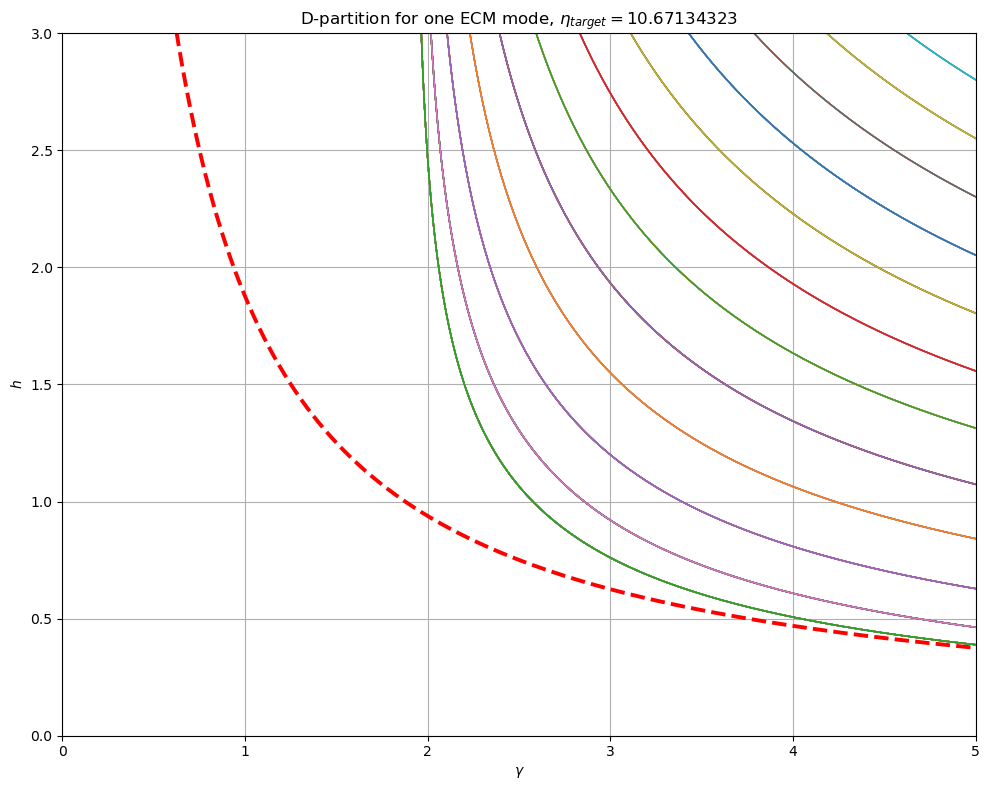

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

if abs(omega0) > 1e-14:
    raise ValueError(
        "This boundary block is exact for omega0 = 0 only. "
        "For omega0 != 0, use a continuation in (eta, gamma, h)."
    )

a = np.arctan(alpha)
EPS = 1e-12

def sn_equation(eta):
    """
    Saddle-node equation for ECM existence boundary, omega0 = 0:
        eta = tan(eta + arctan(alpha))
    """
    return eta - np.tan(eta + a)

def find_sn_roots_around(eta_center, span=10*np.pi):
    """
    Find all saddle-node roots in a window around eta_center.

    Since
        d/deta [eta - tan(eta+a)] = 1 - sec^2(eta+a) = -tan^2(eta+a) <= 0,
    the function is monotone on each interval between tangent poles.
    """
    eta_min = eta_center - span
    eta_max = eta_center + span

    # poles of tan(eta + a):
    # eta = pi/2 - a + k*pi
    k_min = int(np.floor((eta_min + a - np.pi/2) / np.pi)) - 2
    k_max = int(np.ceil((eta_max + a - np.pi/2) / np.pi)) + 2

    poles = np.pi/2 - a + np.arange(k_min, k_max + 1) * np.pi
    cuts = [eta_min] + [p for p in poles if eta_min < p < eta_max] + [eta_max]

    roots = []
    for L, R in zip(cuts[:-1], cuts[1:]):
        l = L + EPS
        r = R - EPS

        fl = sn_equation(l)
        fr = sn_equation(r)

        if not (np.isfinite(fl) and np.isfinite(fr)):
            continue

        if fl == 0.0:
            if not any(abs(l - rr) < 1e-10 for rr in roots):
                roots.append(l)
            continue

        if fr == 0.0:
            if not any(abs(r - rr) < 1e-10 for rr in roots):
                roots.append(r)
            continue

        if fl * fr > 0:
            continue

        try:
            sol = root_scalar(sn_equation, bracket=[l, r], method="brentq")
            root = sol.root
            if not any(abs(root - rr) < 1e-10 for rr in roots):
                roots.append(root)
        except ValueError:
            pass

    return np.array(sorted(roots))

def boundary_curve_from_eta_sn(eta_sn, h_vals):
    """
    For a given saddle-node root eta_sn, return the corresponding
    boundary gamma(h) = K / h.
    """
    psi = eta_sn + a
    c = np.cos(psi)

    # For a valid saddle-node boundary we need cos(psi) < 0,
    # because 1 = -C cos(psi) with C = gamma*h*sqrt(1+alpha^2) > 0.
    if c >= -1e-12:
        return None

    K = -1.0 / (np.sqrt(1.0 + alpha**2) * c)
    gamma_vals = K / h_vals

    mask = (
        np.isfinite(gamma_vals)
        & (gamma_vals >= GAMMA_MIN)
        & (gamma_vals <= GAMMA_MAX)
    )

    return gamma_vals[mask], h_vals[mask], K

def plot_ecm_existence_boundary(
    eta_seed,
    eta_span=10*np.pi,
    n_h=4000
):
    """
    Plot D-partition together with the existence boundary
    of the selected ECM branch around eta_seed.
    """
    sn_roots = find_sn_roots_around(eta_seed, span=eta_span)

    if len(sn_roots) == 0:
        raise RuntimeError("No saddle-node roots were found near the selected mode.")

    idx = np.searchsorted(sn_roots, eta_seed, side="left")
    left_sn = sn_roots[idx - 1] if idx > 0 else None
    right_sn = sn_roots[idx] if idx < len(sn_roots) else None

    print("Selected ECM branch seed:")
    print(f"eta_seed = {eta_seed:.12f}")
    print("Nearest SN roots:")
    print("left SN  =", left_sn)
    print("right SN =", right_sn)

    h_vals = np.linspace(max(H_MIN, 1e-3), H_MAX, n_h)

    plt.figure(figsize=(10, 8))

    
    # selected existence boundaries
    first_label = True
    for eta_sn in [left_sn, right_sn]:
        if eta_sn is None:
            continue

        out = boundary_curve_from_eta_sn(eta_sn, h_vals)
        if out is None:
            continue

        gamma_vals, h_plot, K = out
        if len(gamma_vals) == 0:
            continue

        plt.plot(
            gamma_vals,
            h_plot,
            "r--",
            lw=2.8,
            label="ECM existence boundary" if first_label else None
        )
        first_label = False

    for br in branches:
        # x = gamma, y = h
        plt.plot(br[:, 1], br[:, 2], linewidth=1.0)


    plt.xlim(0, 5)
    plt.ylim(0, 3)
    plt.xlabel(r'$\gamma$')
    plt.ylabel(r'$h$')
    plt.title(rf'D-partition for one ECM mode, $\eta_{{target}}={TARGET_ETA}$')
    plt.grid(True)
    plt.tight_layout()
    
# ============================================================
# CALL
# ============================================================

plot_ecm_existence_boundary(
    eta_seed=eta_seed,
    eta_span=10*np.pi,
    n_h=4000
)